In [39]:
#simulare con Monte Carlo (Metropolis) una particella soggetta ad un Potenziale Double Well 
#in D dimensioni a contatto termico con un reservoir a temperatura T.
import jax 
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functools

In [40]:
#definiamo il potenziale in modo che x1 sia la variabile lenta e x2,...,xD siano le variabili veloci
@jax.jit
def V(x, a=1.0, b=1.0):
    return a * (x[0]**2 - b)**2 + 0.5 * jnp.sum(x[1:]**2)

In [41]:
#genera una condigurazione iniziale casuale usando una gaussiana standard
@functools.partial(jax.jit, static_argnums=(1,))
def generate_config(key, D):
    key, subkey = jax.random.split(key)
    x = jax.random.normal(subkey, shape=(D,))
    return x, key

In [42]:
#genera un numero casuale con una gaussiana standard D dim (per eta: rumore termico)
@functools.partial(jax.jit, static_argnums=(1,))
def generate_normal(key,D):
    key, subkey = jax.random.split(key)
    x = jax.random.normal(subkey, shape=(D,))
    return x, key

#da uniforme:
@jax.jit
def generate_uniform(key):
    key, subkey = jax.random.split(key)
    x = jax.random.uniform(subkey)
    return x, key

In [43]:
#funzione di accettazione di Metropolis
@jax.jit
def metropolis_acceptance(delta_E, T):
    A = jnp.where(delta_E <= 0, 1.0, jnp.exp(-delta_E / T))
    return A

#funzione per eseguire un passo di Metropolis
@jax.jit
def metropolis_step(x, key, T, step_size=0.1):
    D = x.shape[0]
    # nuova configurazione proposta
    eta, key = generate_normal(key,D)
    x_proposed = x + step_size * eta
    # calcola la differenza di energia
    delta_E = V(x_proposed) - V(x)
    # accetta o rifiuta la nuova configurazione
    accept_prob = metropolis_acceptance(delta_E, T)
    u, key = generate_uniform(key)
    accept = u < accept_prob
    x_new = jnp.where(accept, x_proposed, x)
    return x_new, key, accept

In [44]:
#funzione per eseguire la simulazione
@functools.partial(jax.jit, static_argnums=(1, 2, 3))  # D, T, n_steps statiche
def run_simulation(key, D, T, n_steps, step_size=0.1):
    x, key = generate_config(key, D)

    def body(carry, _):
        x, key, acc = carry
        x, key, accepted = metropolis_step(x, key, T, step_size)
        return (x, key, acc + accepted), x

    (_, _, acceptances), trajectory = jax.lax.scan(
        body, (x, key, 0), None, length=n_steps
    )
    return trajectory, acceptances / n_steps

Acceptance rate: 0.96


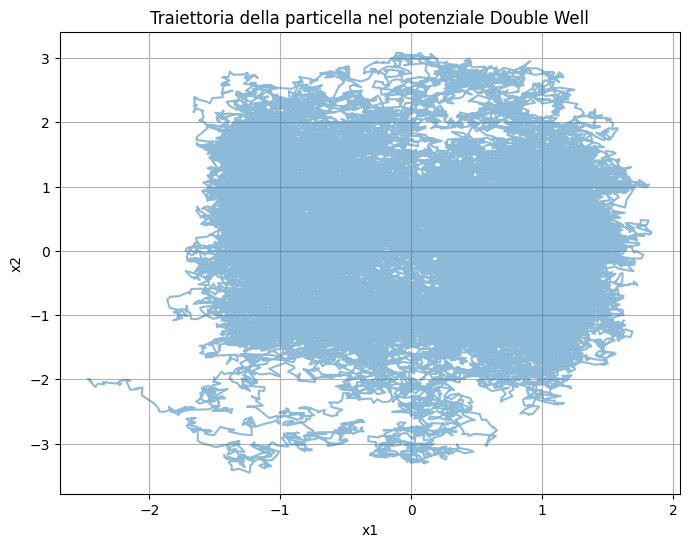

In [45]:
#parametri della simulazione
D = 2  # dimensioni
T = 1.0  # temperatura
n_steps = 70000  # numero di passi
step_size = 0.05  # dimensione del passo

#la simulazione
key = jax.random.PRNGKey(0)
trajectory, acceptance_rate = run_simulation(key, D, T, n_steps, step_size)
print(f"Acceptance rate: {acceptance_rate:.2f}")

#visualizzazione della traiettoria
plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.5)
plt.title("Traiettoria della particella nel potenziale Double Well")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()



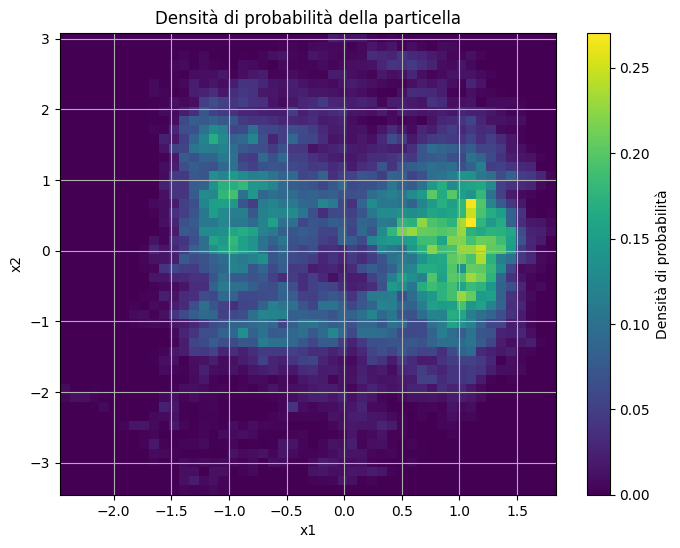

In [46]:
#plot delle zone più visitate dalla particella:
plt.figure(figsize=(8, 6))
plt.hist2d(trajectory[:, 0], trajectory[:, 1], bins=50, density=True, cmap='viridis')
plt.title("Densità di probabilità della particella")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label='Densità di probabilità')
plt.grid()
plt.show()
